# 03 · NLLB-200 for Assamese, Meiteilon & Mizo (zero-shot → fine-tune → evaluate)

Baseline track. **NLLB-200** (Meta) is many-to-many and covers Assamese (`asm_Beng`),
Meiteilon (`mni_Beng`) and Mizo (`lus_Latn`). Same pipeline as notebook 02 for direct comparison:

1. **zero-shot** on our held-out test sets (both directions),
2. **fine-tune** one many-to-many model on our `data_clean/` train splits,
3. **evaluate** before vs. after (chrF++ / spBLEU) with analytic views.

## 0 · Environment check

In [1]:
import importlib, subprocess, sys
REQ = ["torch","transformers","datasets","accelerate","sacrebleu","sentencepiece",
       "matplotlib","pandas","numpy"]
missing = [m for m in REQ if importlib.util.find_spec(m) is None]
if missing:
    print("installing:", missing)
    subprocess.run([sys.executable,"-m","pip","install","--no-input",*missing], check=True)
else:
    print("all libraries present")
import torch, transformers
print("torch", torch.__version__, "| transformers", transformers.__version__)
print("CUDA:", torch.cuda.is_available(), "| GPUs:", torch.cuda.device_count(),
      "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

all libraries present


/data/sujay/miniconda3/envs/wmt_2026_indic/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch 2.8.0+cu128 | transformers 4.45.2
CUDA: True | GPUs: 3 | NVIDIA RTX A6000


## 1 · Config

In [2]:
import os
from dataclasses import dataclass, field

@dataclass
class CFG:
    SMOKE_TEST: bool = False        # False = FULL data (real baseline). True = tiny dry-run only.

    # display name -> (NLLB code, folder under data_clean/)
    langs: dict = field(default_factory=lambda: {
        "Assamese":  ("asm_Beng", "Assamese"),
        "Meiteilon": ("mni_Beng", "Manipuri"),   # NLLB: Bengali-script Meitei only
        "Mizo":      ("lus_Latn", "Mizo"),
    })
    directions: tuple = ("en2x", "x2en")          # both ways

    model_name: str = "facebook/nllb-200-distilled-600M"  # or -1.3B / facebook/nllb-200-3.3B

    data_dir: str = "data_clean"
    out_dir:  str = "runs/nllb200"

    gpu: int = 0
    eval_beams: int = 5
    max_len: int = 256
    infer_batch: int = 32

    epochs: float = 3.0
    lr: float = 3e-5
    train_batch: int = 16
    grad_accum: int = 1
    warmup_ratio: float = 0.05
    weight_decay: float = 0.01
    fp16: bool = True

    def __post_init__(self):
        if self.SMOKE_TEST:
            self.epochs = 1.0; self.eval_sample = 120; self.train_cap = 1000; self.dev_cap = 200
        else:
            self.eval_sample = None; self.train_cap = None; self.dev_cap = None   # FULL data

cfg = CFG()
DEVICE = f"cuda:{cfg.gpu}" if __import__("torch").cuda.is_available() else "cpu"
os.makedirs(cfg.out_dir, exist_ok=True)
print("SMOKE_TEST =", cfg.SMOKE_TEST, "| device =", DEVICE, "| model =", cfg.model_name)

SMOKE_TEST = False | device = cuda:0 | model = facebook/nllb-200-distilled-600M


## 2 · Load cleaned data

In [3]:
import pandas as pd, numpy as np, wmt_data as D
# TRAIN ON ALL DATA (decision 2026-06-15): data_clean train+dev+test + the 2025 gold pairs, merged and
# deduped by wmt_data.parallel_pairs — NO held-out split. Real eval = blind 2026 gold via _predict_gold.py.
def load_split(folder, split):
    return pd.read_csv(os.path.join(cfg.data_dir, folder, f"{split}.tsv"), sep="\t").dropna()

DATA = {}
for lg,(code,folder) in cfg.langs.items():
    DATA[lg] = {sp: load_split(folder, sp) for sp in ["train","dev","test"]}
    DATA[lg]["all"] = pd.DataFrame(D.parallel_pairs(folder), columns=["en","tgt"])   # all splits + 2025 gold
display(pd.DataFrame([{"lang":lg, "ALL":len(DATA[lg]["all"]),
                       **{sp:len(DATA[lg][sp]) for sp in ["train","dev","test"]}}
                      for lg in cfg.langs]).set_index("lang"))

,ALL,train,dev,test
lang,,,,
Assamese,51056,45129,1987,2000
Meiteilon,24734,20539,1143,1144
Mizo,51043,45155,1989,2000


## 3 · Model loading & translation helper
NLLB sets the **source** language on the tokenizer (`tok.src_lang`) and forces the **target** via
`forced_bos_token_id`. One model serves every direction.

In [4]:
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

_TOK = AutoTokenizer.from_pretrained(cfg.model_name)
_MODEL = AutoModelForSeq2SeqLM.from_pretrained(cfg.model_name).to(DEVICE).eval()
print(f"loaded {cfg.model_name} ({sum(p.numel() for p in _MODEL.parameters())/1e6:.0f}M params)")

def bos_id(code):
    lut = getattr(_TOK, "lang_code_to_id", {}) or {}
    return lut[code] if code in lut else _TOK.convert_tokens_to_ids(code)

@torch.no_grad()
def translate(texts, src_code, tgt_code, model=None, bs=None, beams=None):
    mdl = model or _MODEL
    bs = bs or cfg.infer_batch; beams = beams or cfg.eval_beams
    _TOK.src_lang = src_code
    out = []
    for i in range(0, len(texts), bs):
        enc = _TOK(list(texts[i:i+bs]), truncation=True, padding=True,
                   max_length=cfg.max_len, return_tensors="pt").to(mdl.device)
        gen = mdl.generate(**enc, forced_bos_token_id=bos_id(tgt_code),
                           num_beams=beams, max_length=cfg.max_len)
        out.extend(_TOK.batch_decode(gen, skip_special_tokens=True))
    return out

# (source_col, ref_col, src_code, tgt_code, target_is_english) per (lang, direction)
def recipe(lang, direction):
    code_ = cfg.langs[lang][0]
    if direction == "en2x":
        return "en", "tgt", "eng_Latn", code_, False
    else:
        return "tgt", "en", code_, "eng_Latn", True

loaded facebook/nllb-200-distilled-600M (615M params)


## 4 · Scoring (chrF++ primary, spBLEU secondary)
spBLEU uses the FLORES-200 tokenizer for non-English targets; English targets use `13a`.

In [5]:
import sacrebleu
_CHRF = sacrebleu.CHRF(word_order=2)   # chrF++

def make_bleu(target_is_english):
    try:
        return sacrebleu.BLEU(tokenize="13a") if target_is_english else sacrebleu.BLEU(tokenize="flores200")
    except Exception:
        return sacrebleu.BLEU()

def score_corpus(hyps, refs, tgt_is_en):
    bleu = make_bleu(tgt_is_en)
    return {"chrF++": round(_CHRF.corpus_score(hyps,[refs]).score,2),
            "BLEU" if tgt_is_en else "spBLEU": round(bleu.corpus_score(hyps,[refs]).score,2)}

def sent_chrf(h,r): return sacrebleu.sentence_chrf(h,[r]).score

def evaluate(lang, direction, model=None, split="test", n=None):
    src_c, ref_c, sc, tc, tgt_is_en = recipe(lang, direction)
    df = DATA[lang][split]
    if n: df = df.head(n)
    hyps = translate(df[src_c].tolist(), sc, tc, model=model)
    refs = df[ref_c].tolist()
    out = df[[src_c,ref_c]].copy(); out.columns=["source","reference"]; out["hypothesis"]=hyps
    out["sent_chrf"]=[round(sent_chrf(h,r),1) for h,r in zip(hyps,refs)]
    return score_corpus(hyps,refs,tgt_is_en), out

## 5 · Zero-shot baseline

In [6]:
zs_scores, zs_outputs = {}, {}
for lg in cfg.langs:
    for d in cfg.directions:
        sc, out = evaluate(lg, d, n=cfg.eval_sample)
        key=f"{lg}/{d}"; zs_scores[key]=sc; zs_outputs[key]=out
        print(f"{key:22s} {sc}")
zs_table = pd.DataFrame(zs_scores).T; zs_table.index.name="lang/direction"
display(zs_table)

Assamese/en2x          {'chrF++': 33.63, 'spBLEU': 17.61}
Assamese/x2en          {'chrF++': 41.99, 'BLEU': 20.52}
Meiteilon/en2x         {'chrF++': 40.77, 'spBLEU': 23.98}
Meiteilon/x2en         {'chrF++': 53.02, 'BLEU': 26.92}


That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


Mizo/en2x              {'chrF++': 38.98, 'spBLEU': 14.88}


That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


Mizo/x2en              {'chrF++': 41.27, 'BLEU': 21.79}


,chrF++,spBLEU,BLEU
lang/direction,,,
Assamese/en2x,33.63,17.61,NaN
Assamese/x2en,41.99,NaN,20.52
Meiteilon/en2x,40.77,23.98,NaN
Meiteilon/x2en,53.02,NaN,26.92
Mizo/en2x,38.98,14.88,NaN
Mizo/x2en,41.27,NaN,21.79


### 5a · Analytic view

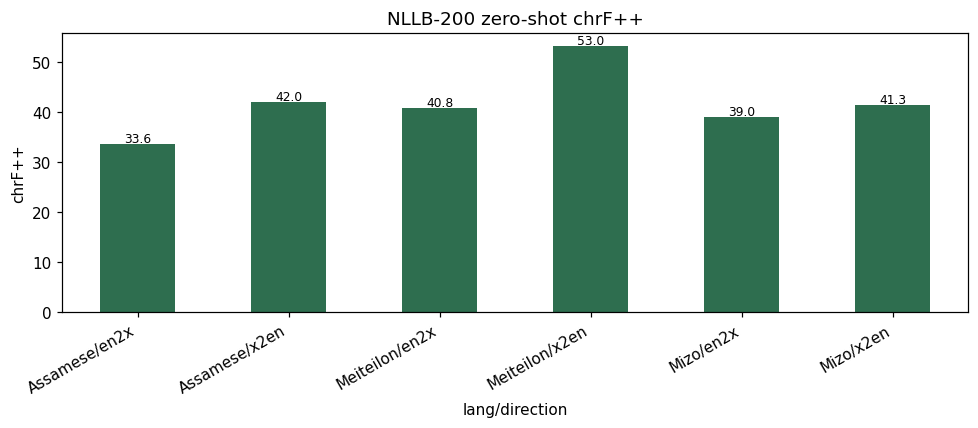

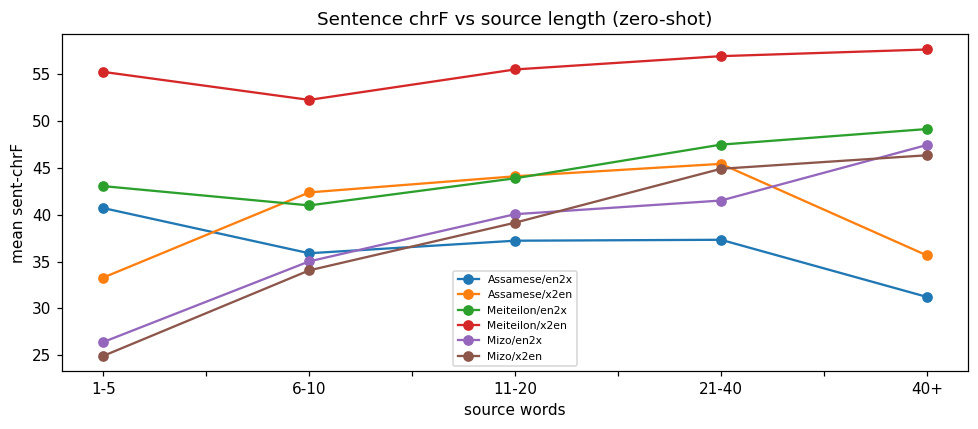

In [7]:
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"]=110
fig, ax = plt.subplots(figsize=(9,4))
zs_table["chrF++"].plot(kind="bar", ax=ax, color="#2e6e4f")
ax.set_title("NLLB-200 zero-shot chrF++"); ax.set_ylabel("chrF++"); plt.xticks(rotation=30, ha="right")
for i,v in enumerate(zs_table["chrF++"]): ax.text(i,v+0.4,f"{v:.1f}",ha="center",fontsize=8)
plt.tight_layout(); plt.show()

def length_curve(out_df):
    d=out_df.copy(); d["w"]=d["source"].str.split().map(len)
    d["bucket"]=pd.cut(d["w"], [0,5,10,20,40,1000], labels=["1-5","6-10","11-20","21-40","40+"])
    return d.groupby("bucket", observed=True)["sent_chrf"].mean()
fig, ax = plt.subplots(figsize=(9,4))
for key,out in zs_outputs.items(): length_curve(out).plot(marker="o", ax=ax, label=key)
ax.set_title("Sentence chrF vs source length (zero-shot)"); ax.set_xlabel("source words"); ax.set_ylabel("mean sent-chrF")
ax.legend(fontsize=7); plt.tight_layout(); plt.show()

### 5b · Best & worst examples

In [8]:
def show_examples(out_df, k=3):
    s=out_df.sort_values("sent_chrf")
    for tag,rows in [("WORST",s.head(k)),("BEST",s.tail(k))]:
        print(f"---- {tag} ----")
        for _,r in rows.iterrows():
            print(f"[{r.sent_chrf:.0f}] SRC: {r.source[:88]}\n      REF: {r.reference[:88]}\n      HYP: {r.hypothesis[:88]}\n")
ex="Mizo/en2x"; print("Examples for", ex, "\n"); show_examples(zs_outputs[ex])

Examples for Mizo/en2x 

---- WORST ----
[0] SRC: portion/ allowance/performance
      REF: CHANVOâ€™
      HYP: hlutna/chhawpchhuahna/thawpchhuahna

[0] SRC: bind, tie . Knot
      REF: ṭàwn
      HYP: Huai, khang, khang, khang, khang, khang, khang, khang, khang, khang, khang, khang, khang

[1] SRC: DO YOU enjoy dramas with fascinating characters and intriguing plots ?
      REF: LEMCHAN thawnthu ṭha tak , thiam taka an chan chu hmuh nawm i ti em ?
      HYP: CHHAWLHAWLHAWLHAWLHAWLHAWLHAWLHAWLHAWLHAWLHAWLHAWLHAWLHAWLHAWLHAWLHAWLHAWLHAWLHAWLHAWLHA

---- BEST ----
[98] SRC: What is your age
      REF: I kum engzat nge ni
      HYP: I kum engzat nge ni?

[100] SRC: 1 - at Hachhek
      REF: 1-Hachhek-ah
      HYP: 1 - Hachhek-ah

[100] SRC: No more water either .
      REF: Tui pawh a awm tawh lo .
      HYP: Tui pawh a awm tawh lo .



## 6 · Fine-tuning (one many-to-many model)
We fine-tune a **single** NLLB model on **all** (language × direction) pairs combined. For each group
we set `tok.src_lang` / `tok.tgt_lang` so inputs and labels get the right language prefixes.

In [ ]:
from datasets import Dataset, concatenate_datasets
from transformers import Seq2SeqTrainer, Seq2SeqTrainingArguments, DataCollatorForSeq2Seq

def build_dataset(split, cap=None):
    parts=[]
    for lg in cfg.langs:
        for d in cfg.directions:
            src_c, ref_c, sc, tc, _ = recipe(lg, d)
            df = DATA[lg][split]
            if cap: df = df.head(cap)
            _TOK.src_lang = sc; _TOK.tgt_lang = tc
            enc = _TOK(df[src_c].tolist(), text_target=df[ref_c].tolist(),
                       truncation=True, max_length=cfg.max_len)
            parts.append(Dataset.from_dict({"input_ids":enc["input_ids"],
                                            "attention_mask":enc["attention_mask"],
                                            "labels":enc["labels"]}))
    return concatenate_datasets(parts).shuffle(seed=42)

train_ds = build_dataset("all", cfg.train_cap)        # ALL data + 2025 gold, both directions
coll = DataCollatorForSeq2Seq(_TOK, model=_MODEL)
args = Seq2SeqTrainingArguments(
    output_dir=cfg.out_dir, overwrite_output_dir=True,
    per_device_train_batch_size=cfg.train_batch, per_device_eval_batch_size=cfg.infer_batch,
    gradient_accumulation_steps=cfg.grad_accum, learning_rate=cfg.lr, num_train_epochs=cfg.epochs,
    warmup_ratio=cfg.warmup_ratio, weight_decay=cfg.weight_decay, fp16=cfg.fp16,
    eval_strategy="no", save_strategy="epoch", save_total_limit=1,   # no held-out -> keep final ckpt
    logging_steps=5 if cfg.SMOKE_TEST else 50, report_to=[], predict_with_generate=False)
trainer = Seq2SeqTrainer(model=_MODEL, args=args, train_dataset=train_ds,
                         data_collator=coll, tokenizer=_TOK)
print(f"=== fine-tuning NLLB on ALL data (train={len(train_ds):,}, both directions, no held-out) ===")
trainer.train()

=== fine-tuning NLLB on ALL data (train=253,666, both directions, no held-out) ===


/data/sujay/miniconda3/envs/wmt_2026_indic/lib/python3.12/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Step,Training Loss


### 6a · Training curve

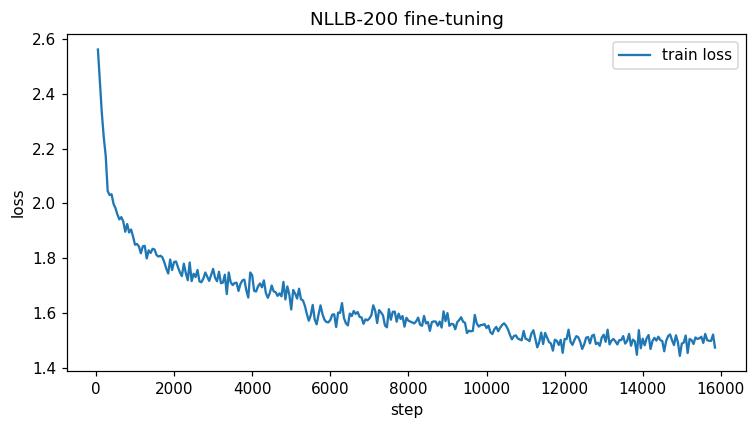

In [10]:
hist=pd.DataFrame(trainer.state.log_history)
fig, ax=plt.subplots(figsize=(7,4))
if "loss" in hist:      ax.plot(hist.dropna(subset=["loss"])["step"], hist.dropna(subset=["loss"])["loss"], label="train loss")
if "eval_loss" in hist: ax.plot(hist.dropna(subset=["eval_loss"])["step"], hist.dropna(subset=["eval_loss"])["eval_loss"], "o-", label="eval loss")
ax.set_xlabel("step"); ax.set_ylabel("loss"); ax.set_title("NLLB-200 fine-tuning"); ax.legend()
plt.tight_layout(); plt.show()

## 7 · Sanity check: before vs. after

In [11]:
ft_scores, ft_outputs = {}, {}
for lg in cfg.langs:
    for d in cfg.directions:
        sc, out = evaluate(lg, d, model=trainer.model, n=cfg.eval_sample)
        key=f"{lg}/{d}"; ft_scores[key]=sc; ft_outputs[key]=out
        print(f"{key:22s} {sc}")
rows=[{"lang/direction":k, "zero-shot":zs_scores[k]["chrF++"], "fine-tuned":ft_scores[k]["chrF++"],
       "Δ":round(ft_scores[k]["chrF++"]-zs_scores[k]["chrF++"],2)} for k in zs_scores]
compare=pd.DataFrame(rows).set_index("lang/direction"); display(compare)

Assamese/en2x          {'chrF++': 37.96, 'spBLEU': 23.5}


That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


Assamese/x2en          {'chrF++': 47.13, 'BLEU': 27.44}
Meiteilon/en2x         {'chrF++': 54.33, 'spBLEU': 43.93}


That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


Meiteilon/x2en         {'chrF++': 60.86, 'BLEU': 37.58}


That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


Mizo/en2x              {'chrF++': 44.96, 'spBLEU': 24.11}


That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


Mizo/x2en              {'chrF++': 47.47, 'BLEU': 28.56}


,zero-shot,fine-tuned,Δ
lang/direction,,,
Assamese/en2x,33.63,37.96,4.33
Assamese/x2en,41.99,47.13,5.14
Meiteilon/en2x,40.77,54.33,13.56
Meiteilon/x2en,53.02,60.86,7.84
Mizo/en2x,38.98,44.96,5.98
Mizo/x2en,41.27,47.47,6.20


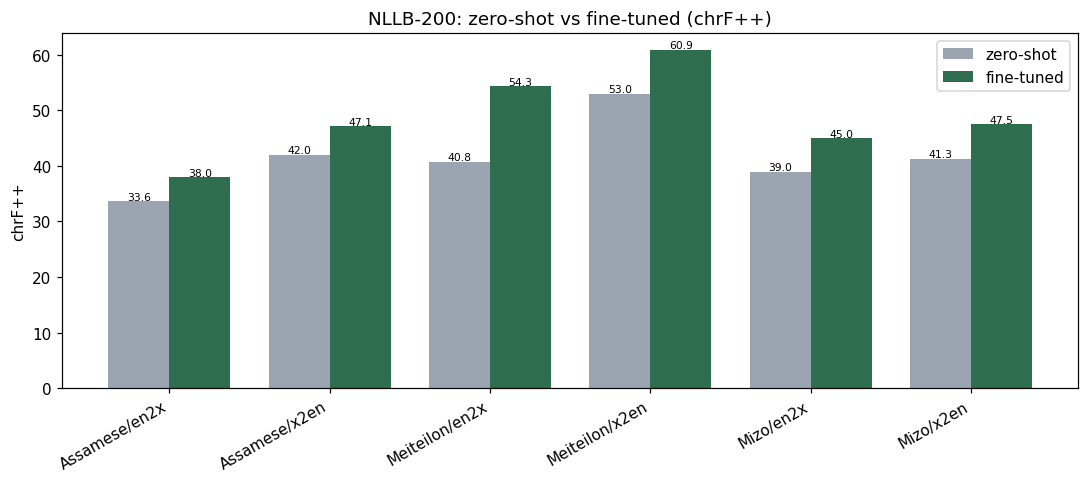

In [12]:
fig, ax=plt.subplots(figsize=(10,4.5))
x=np.arange(len(compare)); w=.38
ax.bar(x-w/2, compare["zero-shot"], w, label="zero-shot", color="#9aa5b1")
ax.bar(x+w/2, compare["fine-tuned"], w, label="fine-tuned", color="#2e6e4f")
ax.set_xticks(x); ax.set_xticklabels(compare.index, rotation=30, ha="right"); ax.set_ylabel("chrF++")
ax.set_title("NLLB-200: zero-shot vs fine-tuned (chrF++)"); ax.legend()
for i,(z,f) in enumerate(zip(compare["zero-shot"],compare["fine-tuned"])):
    ax.text(i-w/2,z+0.3,f"{z:.1f}",ha="center",fontsize=7); ax.text(i+w/2,f+0.3,f"{f:.1f}",ha="center",fontsize=7)
plt.tight_layout(); plt.show()

## 8 · Save model & results

In [13]:
import json
save_to=os.path.join(cfg.out_dir,"nllb200-finetuned")
trainer.save_model(save_to); _TOK.save_pretrained(save_to); print("saved", save_to)
with open(os.path.join(cfg.out_dir,"results.json"),"w") as f:
    json.dump({"smoke_test":cfg.SMOKE_TEST,"model":cfg.model_name,"eval_sample":cfg.eval_sample,
               "zero_shot":zs_scores,"fine_tuned":ft_scores}, f, ensure_ascii=False, indent=2)
compare.to_csv(os.path.join(cfg.out_dir,"compare_chrf.csv"))
print("wrote", os.path.join(cfg.out_dir,"results.json"), "+ compare_chrf.csv")

saved runs/nllb200/nllb200-finetuned
wrote runs/nllb200/results.json + compare_chrf.csv
